# Spam / Ham Classification — End-to-End ML Pipeline

**Goal:** Build and evaluate multiple supervised classifiers that distinguish spam from legitimate (ham) messages, using a comprehensive text-preprocessing pipeline and class balancing.

**Pipeline overview:**
1. Data Loading & Exploration (EDA)
2. **Comprehensive Text Preprocessing** — placeholder tokens, contraction/slang expansion, emoticons, repeated-char squeezing, lemmatization
3. **Feature Engineering** — word TF-IDF + character n-grams + hand-crafted meta-features, fused together
4. **Class Balancing** — SMOTE applied to the *training data only* (50/50)
5. Model Training — Naive Bayes, Logistic Regression, Linear SVM, Random Forest, Gradient Boosting
6. Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC
7. Hyperparameter Tuning (GridSearchCV)
8. Final Model & Inference Demo

> **Note on balancing:** We balance only the training split. The test set is left at its natural ~13 % spam rate so that reported metrics reflect real-world performance. Balancing the whole dataset before splitting leaks information and inflates scores.

## 0 · Dependency Setup (run once)

In [1]:
import sys, subprocess

# Install any missing packages INTO THE KERNEL'S OWN ENVIRONMENT.
# Using sys.executable guarantees we install where this notebook is actually running.
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'nltk', 'scikit-learn', 'imbalanced-learn',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'wordcloud'
])
print('Dependencies ready.')

Dependencies ready.


## 1 · Imports & Setup

In [1]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# imbalanced-learn: SMOTE + a pipeline that resamples TRAIN folds only
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


## 2 · Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
print(f'Shape: {df.shape}')
df.head(10)

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
print('--- Missing Values ---')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after deduplication: {df.shape}')

--- Missing Values ---
label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after deduplication: (5169, 2)


Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam ratio: 12.63%  (imbalanced -> we will balance the training set later)


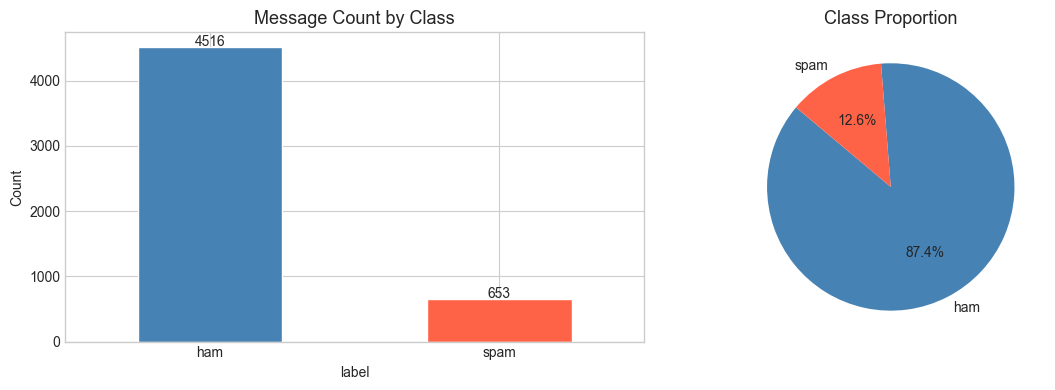

In [4]:
class_counts = df['label'].value_counts()
print('Class distribution:')
print(class_counts)
print(f'\nSpam ratio: {class_counts["spam"] / len(df):.2%}  (imbalanced -> we will balance the training set later)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white', rot=0)
axes[0].set_title('Message Count by Class', fontsize=13)
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(int(bar.get_height())), ha='center')
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['steelblue','tomato'], startangle=140)
axes[1].set_title('Class Proportion', fontsize=13)
plt.tight_layout(); plt.show()

## 3 · Exploratory Data Analysis (EDA) & Meta-Feature Construction

These hand-crafted features are computed from the **raw** message (before cleaning destroys case, punctuation and digits). The EDA below shows they separate the classes — so later we will **fuse them into the model** instead of using them for plots only.

In [ ]:
df['char_count']   = df['message'].str.len()                                           # count total number of characters in each message
df['word_count']   = df['message'].str.split().apply(len)                              # split message into words then count how many words there are
df['punct_count']  = df['message'].apply(lambda x: sum(c in string.punctuation for c in x))  # count how many characters are punctuation marks
df['upper_count']  = df['message'].apply(lambda x: sum(c.isupper() for c in x))       # count how many characters are uppercase letters
df['digit_count']  = df['message'].apply(lambda x: sum(c.isdigit() for c in x))       # count how many characters are numeric digits

df['upper_ratio']  = df['upper_count'] / df['char_count'].clip(lower=1)               # calculate proportion of uppercase letters, clip(lower=1) prevents division by zero on empty messages

df['exclam_count'] = df['message'].str.count('!')                                      # count the number of exclamation marks in each message
df['has_currency'] = df['message'].str.contains(r'[£$€]').astype(int)                 # flag messages containing a currency symbol (1 if yes, 0 if no)
df['has_url']      = df['message'].str.contains(r'http|www\.', case=False).astype(int) # flag messages containing a URL, case=False catches Http, HTTP etc
df['has_phone']    = df['message'].str.contains(r'\d{5,}').astype(int)                # flag messages with a sequence of 5+ digits, a rough proxy for a phone number

# define the list of new feature column names for easy reference later
META_COLS = ['char_count','word_count','punct_count','upper_count','digit_count',
             'upper_ratio','exclam_count','has_currency','has_url','has_phone']

# group by label (ham/spam), compute the mean of each feature, transpose so features are rows, round to 3 decimal places
print(df.groupby('label')[META_COLS].mean().T.round(3))

label            ham     spam
char_count    70.459  137.891
word_count    14.135   23.681
punct_count    3.866    5.649
upper_count    3.904   15.247
digit_count    0.290   15.447
upper_ratio    0.058    0.110
exclam_count   0.175    0.694
has_currency   0.004    0.332
has_url        0.000    0.139
has_phone      0.001    0.766


: 

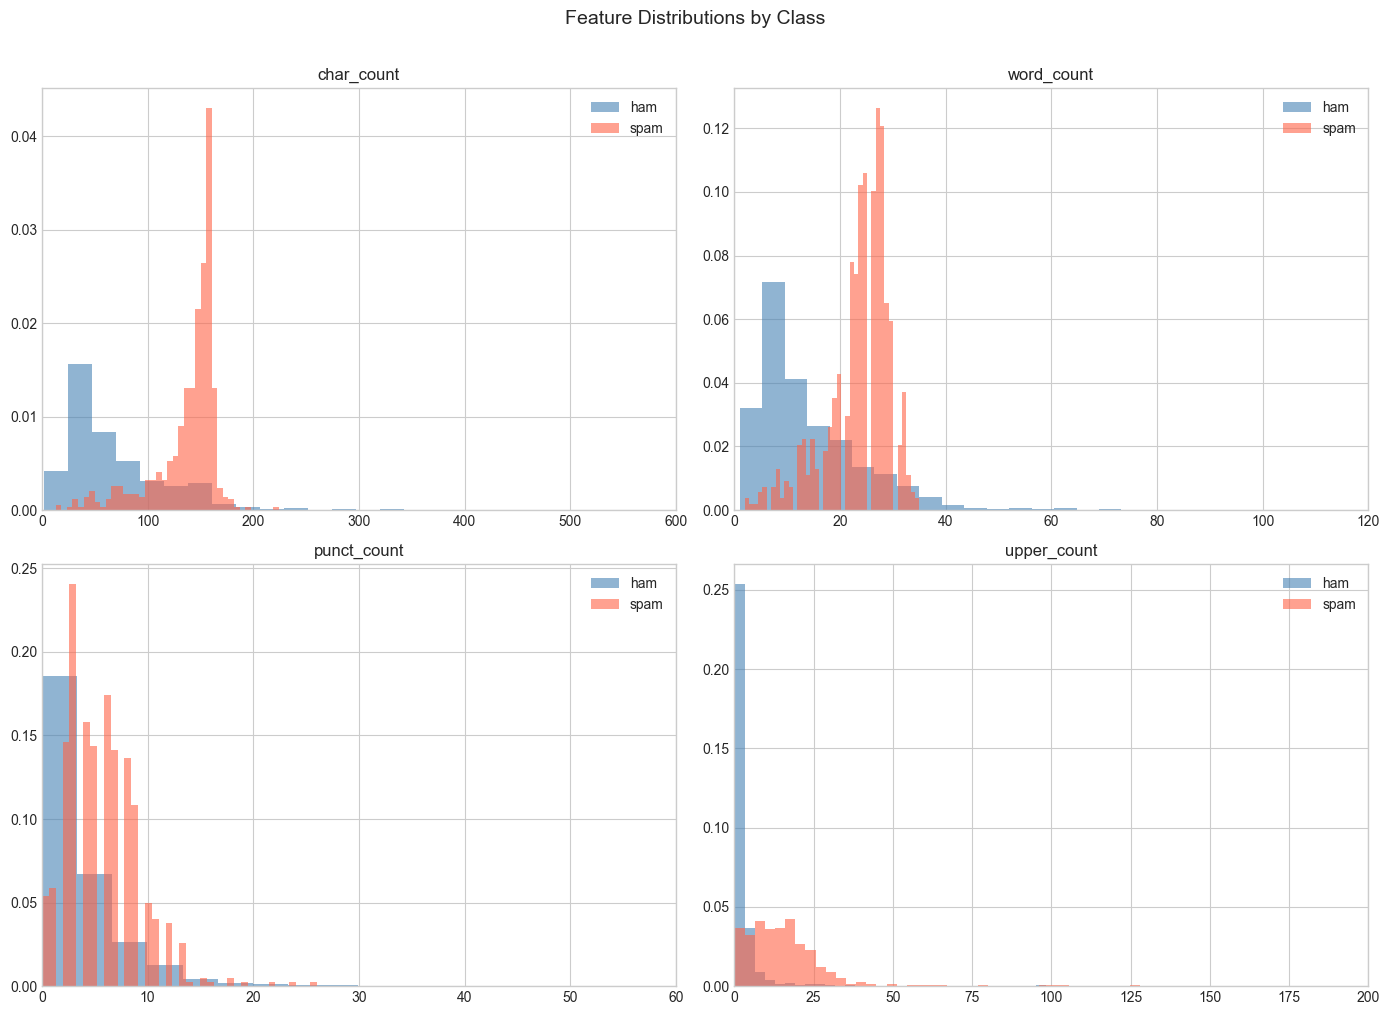

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat, xlim in zip(axes.flatten(),
                          ['char_count','word_count','punct_count','upper_count'],
                          [600, 120, 60, 200]):
    for label, color in zip(['ham','spam'], ['steelblue','tomato']):
        ax.hist(df[df['label']==label][feat], bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=12); ax.set_xlim(0, xlim); ax.legend()
plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

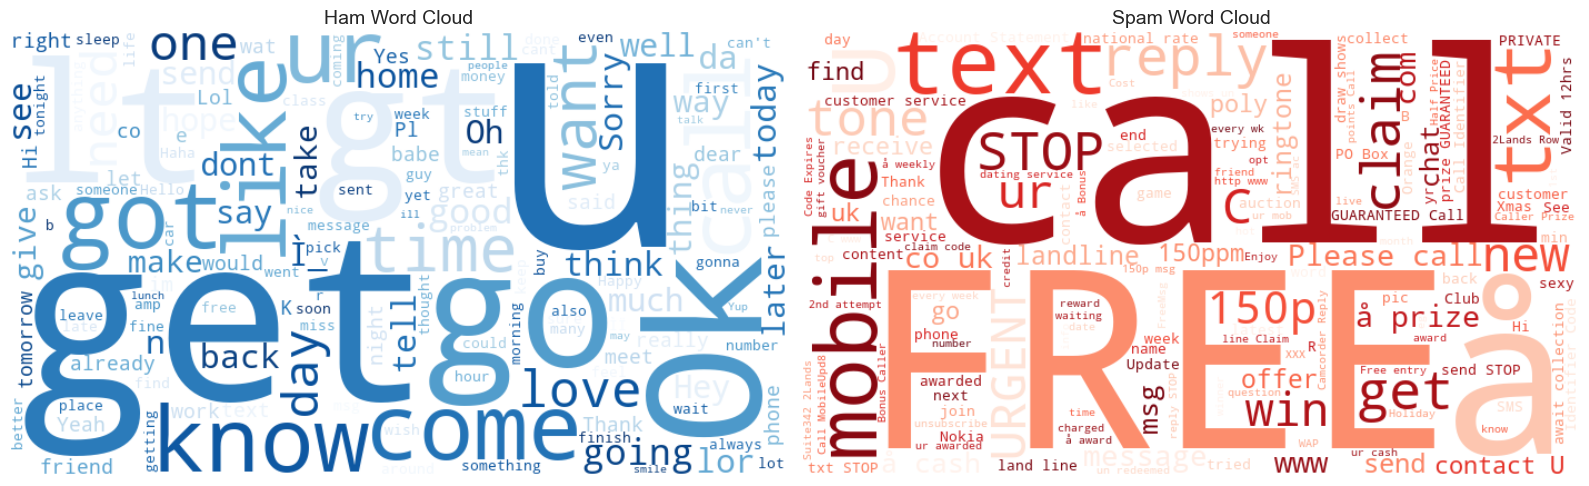

In [7]:
stop_words = set(stopwords.words('english'))
ham_text  = ' '.join(df[df['label']=='ham']['message'])
spam_text = ' '.join(df[df['label']=='spam']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, text, title, cmap in zip(axes, [ham_text, spam_text],
                                 ['Ham Word Cloud','Spam Word Cloud'], ['Blues','Reds']):
    wc = WordCloud(width=700, height=400, background_color='white',
                   stopwords=stop_words, colormap=cmap, max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(title, fontsize=14)
plt.tight_layout(); plt.show()

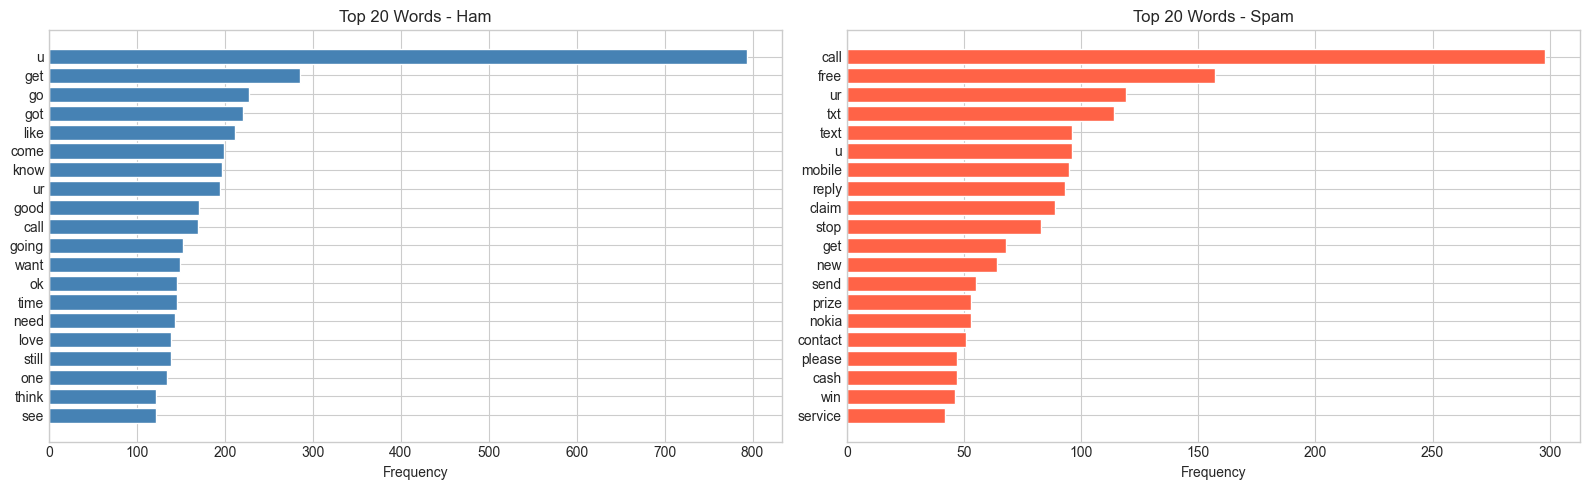

In [8]:
def top_words(texts, n=20):
    toks = [w.lower() for msg in texts for w in msg.split()
            if w.lower() not in stop_words and w.isalpha()]
    return Counter(toks).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label, color in zip(axes, ['ham','spam'], ['steelblue','tomato']):
    words, counts = zip(*top_words(df[df['label']==label]['message']))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words - {label.capitalize()}', fontsize=12); ax.set_xlabel('Frequency')
plt.tight_layout(); plt.show()

## 4 · Comprehensive Text Preprocessing

This applies **every** technique discussed, in a deliberate order (steps that need punctuation/case run before we strip them):

1. Lowercase
2. **Emoticon** mapping (`:)` -> `smileface`) — done before punctuation is removed
3. **Contraction** expansion (`don't` -> `do not`)
4. **Placeholder tokens**: URLs -> `url`, emails -> `email`, currency -> `money`, 5+ digit numbers -> `longnum`, other numbers -> `num`
5. **Repeated-character squeeze** (`freeeee` -> `free`)
6. Strip remaining non-alphabetic characters
7. Tokenize, **SMS slang normalization** (`u` -> `you`), stopword removal, **lemmatization**

> The optional generic spell-checker is included in the next cell but **left off by default** — on SMS text it tends to "correct" deliberate slang and is slow, usually hurting F1. Slang normalization above is the domain-appropriate substitute.

In [9]:
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not","can't":"cannot","won't":"will not","i'm":"i am","it's":"it is",
    "you're":"you are","they're":"they are","we're":"we are","i've":"i have","you've":"you have",
    "i'll":"i will","you'll":"you will","he's":"he is","she's":"she is","that's":"that is",
    "there's":"there is","what's":"what is","let's":"let us","didn't":"did not","doesn't":"does not",
    "isn't":"is not","aren't":"are not","wasn't":"was not","weren't":"were not","haven't":"have not",
    "hasn't":"has not","wouldn't":"would not","couldn't":"could not","shouldn't":"should not",
}

SLANG = {
    "u":"you","ur":"your","r":"are","y":"why","pls":"please","plz":"please","thx":"thanks",
    "tnx":"thanks","gud":"good","gr8":"great","b4":"before","wat":"what","wen":"when","wid":"with",
    "da":"the","dis":"this","dat":"that","luv":"love","msg":"message","txt":"text","kk":"ok",
}

EMOTICONS = {
    ":)":" smileface ",":-)":" smileface ",":(":" sadface ",":-(":" sadface ",
    ":d":" grinface ",";)":" winkface ",":p":" tongueface ","<3":" heartface ",
}

def clean_text(text: str) -> str:
    text = text.lower()
    for emo, tok in EMOTICONS.items():
        text = text.replace(emo, tok)
    for c, full in CONTRACTIONS.items():
        text = text.replace(c, full)
    text = re.sub(r'http\S+|www\.\S+', ' url ',     text)
    text = re.sub(r'\S+@\S+',           ' email ',   text)
    text = re.sub(r'[£$€]',             ' money ',   text)
    text = re.sub(r'\b\d+\s?(?:p|pence|pounds?)\b', ' money ', text)
    text = re.sub(r'\b\d{5,}\b',        ' longnum ', text)
    text = re.sub(r'\b\d+\b',           ' num ',     text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # freeeee -> free
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    out = []
    for tok in word_tokenize(text):
        tok = SLANG.get(tok, tok)
        if tok in stop_words or len(tok) <= 1:
            continue
        out.append(lemmatizer.lemmatize(tok))
    return ' '.join(out)

df['clean_message'] = df['message'].apply(clean_text)

for _, row in df[df['label']=='spam'].head(3).iterrows():
    print(f'[RAW]   {row["message"][:110]}')
    print(f'[CLEAN] {row["clean_message"][:110]}\n')

[RAW]   Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question
[CLEAN] free entry num wkly comp win fa cup final tkts st may num text fa longnum receive entry question std text rate

[RAW]   FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb o
[CLEAN] freemsg hey darling num week word back like fun still tb ok xx std chgs send money num num rcv

[RAW]   WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 090
[CLEAN] winner valued network customer selected receivea money num prize reward claim call longnum claim code kl valid



In [10]:
# OPTIONAL: generic spell-correction. Off by default (slow + harmful on SMS slang).
USE_SPELLCHECK = False

if USE_SPELLCHECK:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyspellchecker'])
    from spellchecker import SpellChecker
    spell = SpellChecker()
    def spell_correct(text):
        return ' '.join(spell.correction(w) or w for w in text.split())
    df['clean_message'] = df['clean_message'].apply(spell_correct)
    print('Spell-correction applied.')
else:
    print('Spell-correction skipped (recommended for SMS). Set USE_SPELLCHECK=True to enable.')

Spell-correction skipped (recommended for SMS). Set USE_SPELLCHECK=True to enable.


## 5 · Feature Engineering — Fused Representation

A single `ColumnTransformer` produces and concatenates three feature blocks:

| Block | What it captures |
|---|---|
| **Word TF-IDF** (1–2 grams, `min_df`/`max_df` filtered) | normal vocabulary signal |
| **Character n-grams** (`char_wb`, 2–4) | obfuscation like `fr33` / `w1n`, sub-word patterns |
| **Meta-features** (scaled) | length, punctuation, uppercase, digits, currency/URL/phone flags |

The meta-features that were only plotted before are now part of the model input.

In [11]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])      # ham=0, spam=1

X = df[['clean_message'] + META_COLS]
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train spam rate: {y_train.mean():.2%} | Test spam rate: {y_test.mean():.2%}')

def build_features():
    """Fresh ColumnTransformer: word TF-IDF + char n-grams + scaled meta-features."""
    return ColumnTransformer([
        ('word_tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                       sublinear_tf=True, min_df=2, max_df=0.9), 'clean_message'),
        ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                                       max_features=2000, sublinear_tf=True, min_df=2), 'clean_message'),
        ('meta', StandardScaler(with_mean=False), META_COLS),
    ])

# Inspect the fused dimensionality
_demo = build_features().fit(X_train, y_train)
print(f'\nFused feature dimensionality: {_demo.transform(X_train).shape[1]}')

Train: 4135 | Test: 1034
Train spam rate: 12.62% | Test spam rate: 12.67%

Fused feature dimensionality: 7010


## 6 · Class Balancing — SMOTE (Training Data Only)

SMOTE synthesises new minority-class (spam) samples until the training set is **50/50**. It runs **inside** the model pipeline, so during cross-validation it only ever sees the training folds — the held-out data is never balanced. The cell below illustrates the effect on the training split.

Before SMOTE -> ham: 3613, spam: 522  (12.6% spam)
After  SMOTE -> ham: 3613, spam: 3613  (50.0% spam)


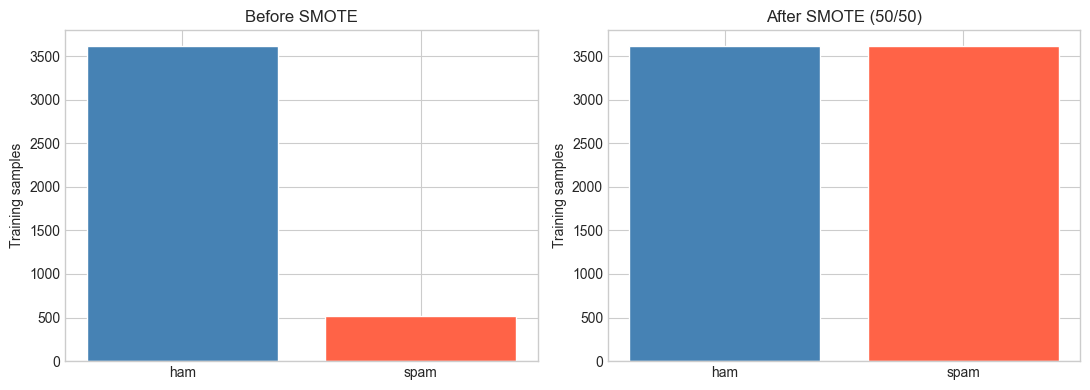

In [12]:
feats_train = build_features().fit_transform(X_train, y_train)
_, y_bal = SMOTE(random_state=RANDOM_STATE).fit_resample(feats_train, y_train)

before, after = Counter(y_train), Counter(y_bal)
print(f'Before SMOTE -> ham: {before[0]}, spam: {before[1]}  ({before[1]/sum(before.values()):.1%} spam)')
print(f'After  SMOTE -> ham: {after[0]}, spam: {after[1]}  ({after[1]/sum(after.values()):.1%} spam)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(axes, [before, after], ['Before SMOTE', 'After SMOTE (50/50)']):
    ax.bar(['ham','spam'], [counts[0], counts[1]], color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Training samples')
plt.tight_layout(); plt.show()

## 7 · Model Training — Baseline Comparison (Balanced Pipeline)

Each classifier is wrapped in an `imblearn` pipeline: **features -> SMOTE -> classifier**. The test set stays untouched/imbalanced for honest evaluation.

In [13]:
models = {
    'Multinomial NB':      MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

def make_pipeline(clf):
    return ImbPipeline([
        ('features', build_features()),
        ('balance',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',      clf),
    ])

fitted, results = {}, []
for name, clf in models.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') \
              else pipe.decision_function(X_test)
    fitted[name] = pipe
    results.append({'Model':name,
                    'Accuracy':accuracy_score(y_test, y_pred),
                    'Precision':precision_score(y_test, y_pred),
                    'Recall':recall_score(y_test, y_pred),
                    'F1':f1_score(y_test, y_pred),
                    'ROC-AUC':roc_auc_score(y_test, y_score)})

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1', ascending=False)
print(results_df.map(lambda x: f'{x:.4f}').to_string())

                    Accuracy Precision  Recall      F1 ROC-AUC
Model                                                         
Linear SVM            0.9874    0.9758  0.9237  0.9490  0.9974
Random Forest         0.9874    1.0000  0.9008  0.9478  0.9924
Logistic Regression   0.9855    0.9531  0.9313  0.9421  0.9969
Gradient Boosting     0.9836    0.9318  0.9389  0.9354  0.9936
Multinomial NB        0.9787    0.9160  0.9160  0.9160  0.9903


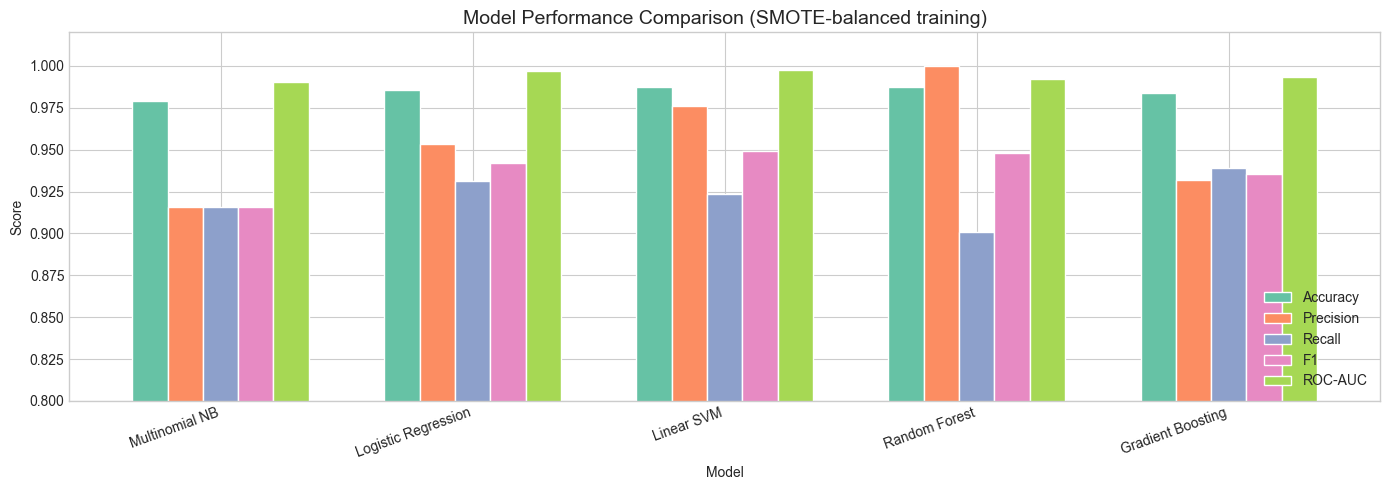

In [14]:
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
rp = pd.DataFrame(results).set_index('Model')[metrics].astype(float)
ax = rp.plot(kind='bar', figsize=(14, 5), width=0.7, edgecolor='white')
ax.set_title('Model Performance Comparison (SMOTE-balanced training)', fontsize=14)
ax.set_ylabel('Score'); ax.set_ylim(0.8, 1.02)
ax.set_xticklabels(rp.index, rotation=20, ha='right'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8 · Confusion Matrices

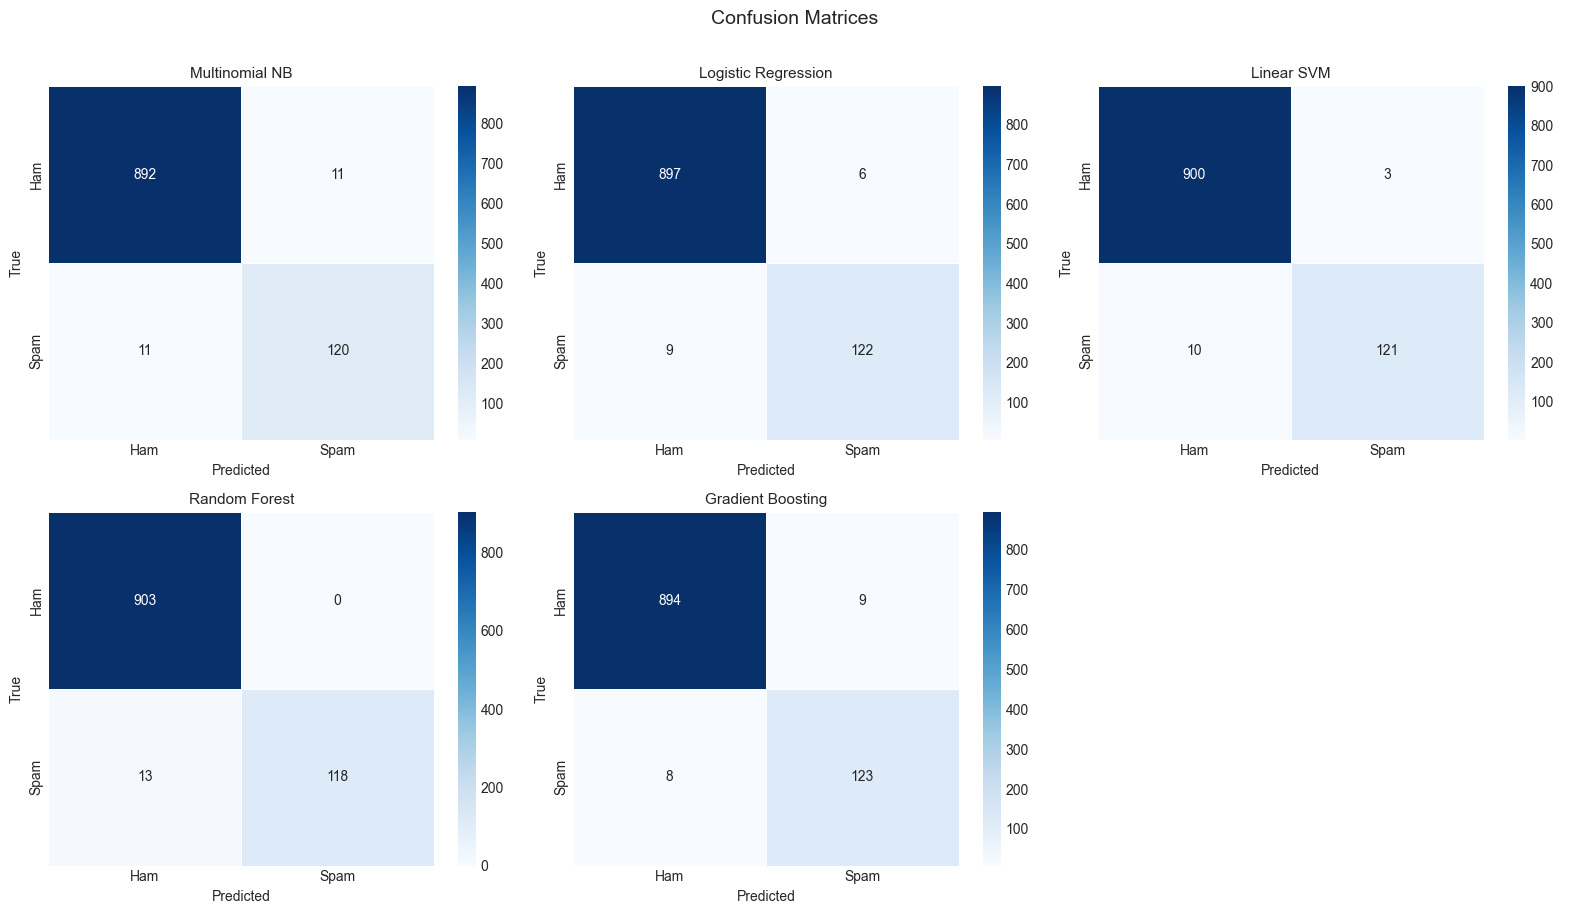

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.flatten()
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', linewidths=0.5,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(name, fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
axes[-1].axis('off')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.01); plt.tight_layout(); plt.show()

## 9 · ROC Curves

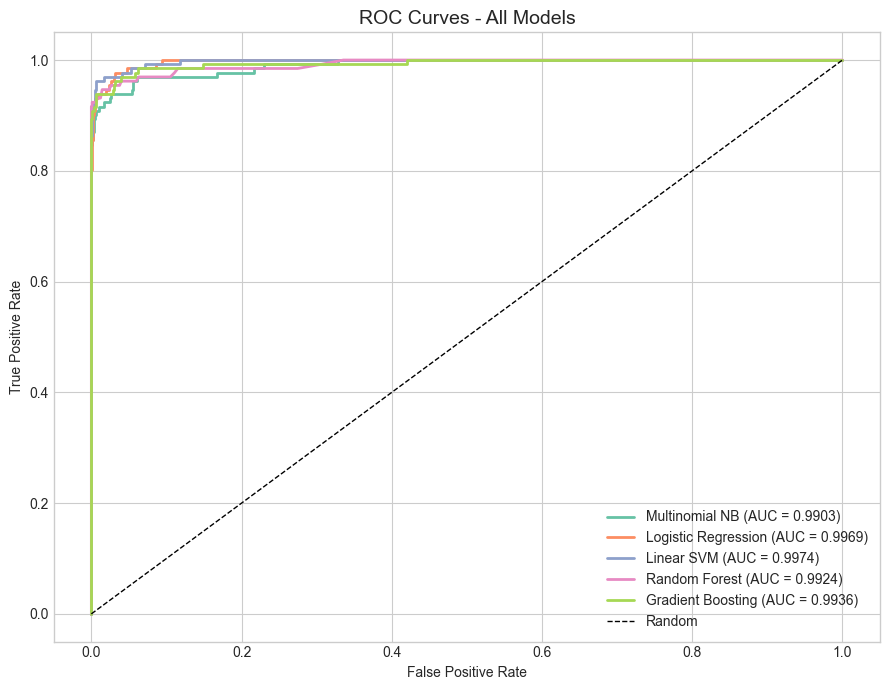

In [16]:
plt.figure(figsize=(9, 7))
for name, pipe in fitted.items():
    y_score = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') \
              else pipe.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, y_score):.4f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models', fontsize=14); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 10 · Cross-Validation (5-Fold, SMOTE inside each fold)

Because SMOTE is a pipeline step, `cross_val_score` resamples only the training portion of every fold — no leakage into validation.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, clf in models.items():
    scores = cross_val_score(make_pipeline(clf), X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} F1 = {scores.mean():.4f} +/- {scores.std():.4f}')

Multinomial NB         F1 = 0.9276 +/- 0.0092
Logistic Regression    F1 = 0.9467 +/- 0.0085
Linear SVM             F1 = 0.9609 +/- 0.0073
Random Forest          F1 = 0.9297 +/- 0.0247
Gradient Boosting      F1 = 0.9400 +/- 0.0190


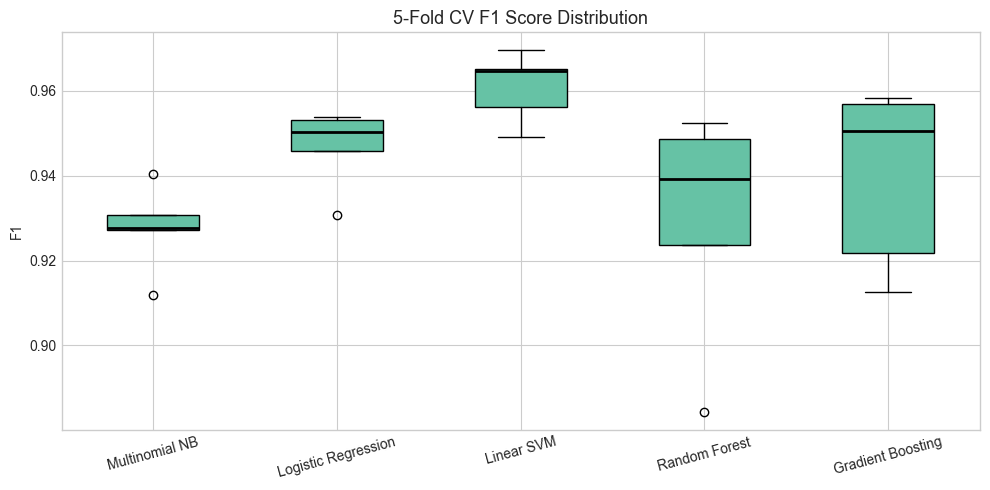

In [18]:
plt.figure(figsize=(10, 5))
plt.boxplot([cv_results[k] for k in cv_results], labels=list(cv_results.keys()),
            patch_artist=True, medianprops=dict(color='black', linewidth=2))
plt.title('5-Fold CV F1 Score Distribution', fontsize=13); plt.ylabel('F1')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 11 · Hyperparameter Tuning — Best Model

Logistic Regression and Linear SVM (the strongest baselines) are tuned with `GridSearchCV`. Note the nested parameter names address steps inside the pipeline, e.g. `features__word_tfidf__max_features`.

In [19]:
lr_grid = {
    'features__word_tfidf__max_features': [4000, 6000],
    'features__word_tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':                             [0.5, 1.0, 5.0, 10.0],
}
lr_gs = GridSearchCV(make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                     lr_grid, cv=5, scoring='f1', n_jobs=-1)
lr_gs.fit(X_train, y_train)
print(f'Best LR params : {lr_gs.best_params_}')
print(f'Best LR CV F1  : {lr_gs.best_score_:.4f}')

Best LR params : {'clf__C': 5.0, 'features__word_tfidf__max_features': 4000, 'features__word_tfidf__ngram_range': (1, 1)}
Best LR CV F1  : 0.9524


In [20]:
svm_grid = {
    'features__word_tfidf__max_features': [4000, 6000],
    'features__word_tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':                             [0.1, 0.5, 1.0, 5.0],
}
svm_gs = GridSearchCV(make_pipeline(LinearSVC(max_iter=4000, random_state=RANDOM_STATE)),
                      svm_grid, cv=5, scoring='f1', n_jobs=-1)
svm_gs.fit(X_train, y_train)
print(f'Best SVM params : {svm_gs.best_params_}')
print(f'Best SVM CV F1  : {svm_gs.best_score_:.4f}')

Best SVM params : {'clf__C': 1.0, 'features__word_tfidf__max_features': 6000, 'features__word_tfidf__ngram_range': (1, 2)}
Best SVM CV F1  : 0.9519


In [21]:
best_model = lr_gs if lr_gs.best_score_ >= svm_gs.best_score_ else svm_gs
best_name  = 'Logistic Regression' if lr_gs.best_score_ >= svm_gs.best_score_ else 'Linear SVM'
print(f'Selected best model: {best_name}  (CV F1 = {best_model.best_score_:.4f})')

Selected best model: Logistic Regression  (CV F1 = 0.9524)


## 12 · Final Evaluation on Held-Out (Imbalanced) Test Set

In [22]:
y_pred_final = best_model.predict(X_test)
print(f'=== Final Model: {best_name} ===')
print(classification_report(y_test, y_pred_final, target_names=['Ham','Spam']))
for k, v in {'Accuracy':accuracy_score(y_test, y_pred_final),
             'Precision':precision_score(y_test, y_pred_final),
             'Recall':recall_score(y_test, y_pred_final),
             'F1':f1_score(y_test, y_pred_final)}.items():
    print(f'  {k:<11}: {v:.4f}')

=== Final Model: Logistic Regression ===
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.97      0.93      0.95       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034

  Accuracy   : 0.9874
  Precision  : 0.9683
  Recall     : 0.9313
  F1         : 0.9494


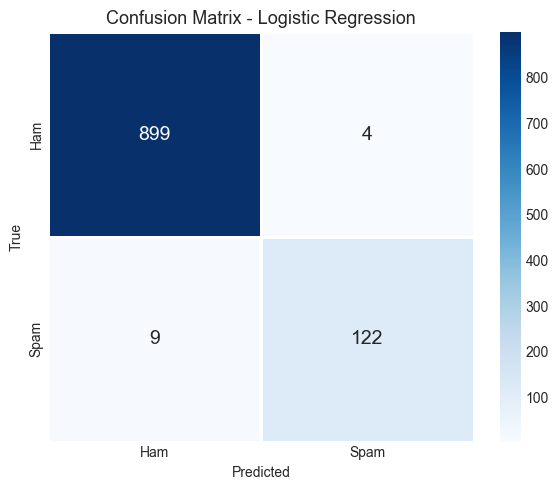

True  Negatives (Ham  -> Ham ): 899
False Positives (Ham  -> Spam): 4  <- ham wrongly flagged
False Negatives (Spam -> Ham ): 9  <- spam that slipped through
True  Positives (Spam -> Spam): 122


In [23]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', linewidths=1, annot_kws={'size':14},
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=13)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives (Ham  -> Ham ): {tn}')
print(f'False Positives (Ham  -> Spam): {fp}  <- ham wrongly flagged')
print(f'False Negatives (Spam -> Ham ): {fn}  <- spam that slipped through')
print(f'True  Positives (Spam -> Spam): {tp}')

## 13 · Feature Importance — Top Discriminative Features

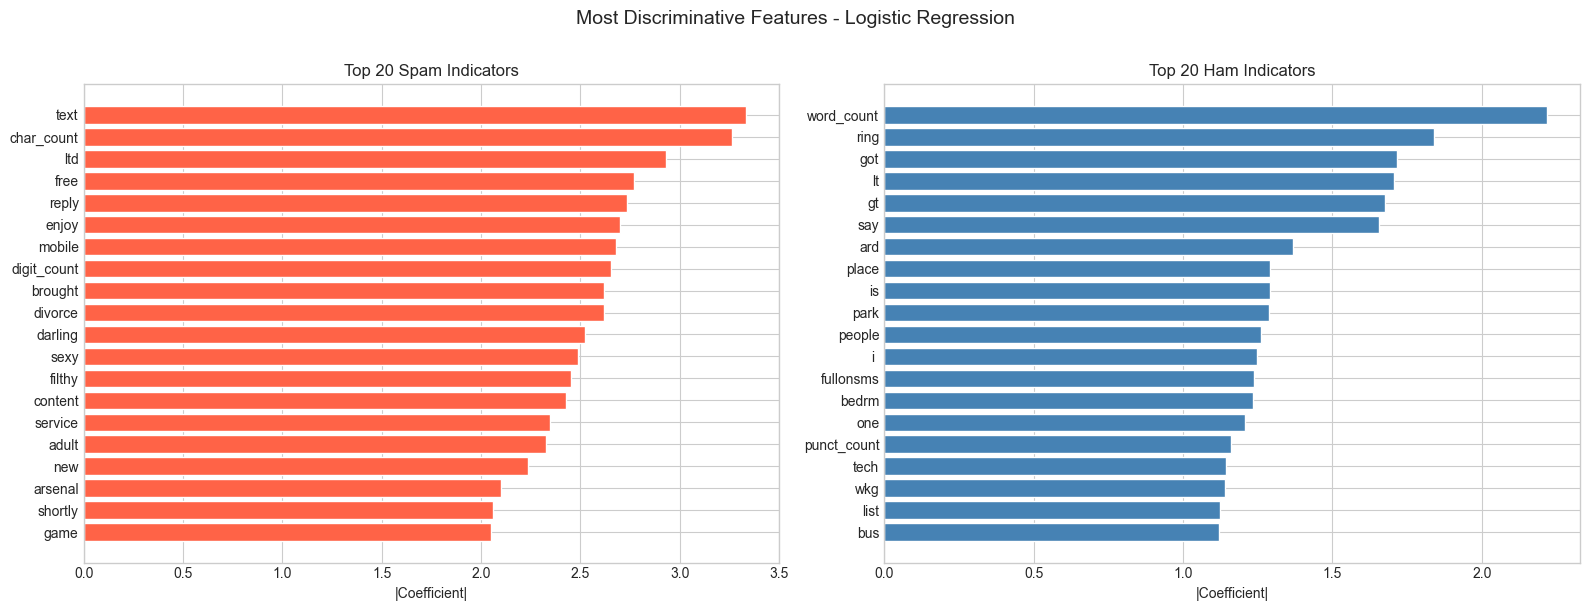

In [24]:
best_pipe = best_model.best_estimator_
feat_names = best_pipe.named_steps['features'].get_feature_names_out()
clf = best_pipe.named_steps['clf']
coef = clf.coef_[0] if clf.coef_.ndim == 2 else clf.coef_

def short(n):   # strip the 'word_tfidf__' / 'meta__' prefixes for readability
    return n.split('__', 1)[-1]

n_top = 20
spam_idx = np.argsort(coef)[-n_top:][::-1]
ham_idx  = np.argsort(coef)[:n_top]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, idx, title, color in zip(axes, [spam_idx, ham_idx],
                                 [f'Top {n_top} Spam Indicators', f'Top {n_top} Ham Indicators'],
                                 ['tomato','steelblue']):
    labels = [short(feat_names[i]) for i in idx]
    ax.barh(labels[::-1], np.abs(coef[idx])[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12); ax.set_xlabel('|Coefficient|')
plt.suptitle(f'Most Discriminative Features - {best_name}', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 14 · Inference Demo

In [25]:
def build_row(message: str) -> pd.DataFrame:
    """Turn a raw message into the same feature columns the model expects."""
    row = {
        'clean_message': clean_text(message),
        'char_count':   len(message),
        'word_count':   len(message.split()),
        'punct_count':  sum(c in string.punctuation for c in message),
        'upper_count':  sum(c.isupper() for c in message),
        'digit_count':  sum(c.isdigit() for c in message),
        'upper_ratio':  sum(c.isupper() for c in message) / max(len(message), 1),
        'exclam_count': message.count('!'),
        'has_currency': int(bool(re.search(r'[£$€]', message))),
        'has_url':      int(bool(re.search(r'http|www\.', message, re.I))),
        'has_phone':    int(bool(re.search(r'\d{5,}', message))),
    }
    return pd.DataFrame([row])

def predict_message(message: str) -> dict:
    row  = build_row(message)
    pred = best_model.predict(row)[0]
    label = le.inverse_transform([pred])[0]
    if hasattr(best_pipe.named_steps['clf'], 'predict_proba'):
        conf = best_model.predict_proba(row)[0][pred]
    else:
        conf = 1 / (1 + np.exp(-abs(best_pipe.decision_function(row)[0])))
    return {'label': label.upper(), 'confidence': f'{conf:.2%}'}

test_messages = [
    "WINNER!! You have been selected to receive a £900 prize. Call 09061701461 now!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "FREE entry! Text WIN to 80085 for your chance to claim a holiday voucher!",
    "Can you send me the lecture notes from today please?",
    "Urgent! Your bank account has been suspended. Verify at http://secure-login.tk now",
]
print(f'{"Message":<63} {"Label":<6} Confidence')
print('-' * 84)
for msg in test_messages:
    r = predict_message(msg)
    print(f'{msg[:62]:<63} {r["label"]:<6} {r["confidence"]}')

Message                                                         Label  Confidence
------------------------------------------------------------------------------------
WINNER!! You have been selected to receive a £900 prize. Call   SPAM   100.00%
Hey, are we still meeting for lunch tomorrow at 1pm?            HAM    99.96%
FREE entry! Text WIN to 80085 for your chance to claim a holid  SPAM   99.92%
Can you send me the lecture notes from today please?            HAM    99.45%
Urgent! Your bank account has been suspended. Verify at http:/  SPAM   96.68%


## 15 · Summary

| Stage | What was done |
|---|---|
| **Dataset** | ~5,170 unique messages; ~13 % spam |
| **Preprocessing** | lowercase, emoticon mapping, contraction + SMS-slang expansion, placeholder tokens (url/email/money/num), repeated-char squeeze, stopword removal, lemmatization |
| **Features** | word TF-IDF (1–2 gram) + char n-grams (2–4) + 10 scaled meta-features, fused in a `ColumnTransformer` |
| **Balancing** | **SMOTE to 50/50 on the training data only**, inside the pipeline (leakage-safe); test set left at natural rate |
| **Models** | Multinomial NB, Logistic Regression, Linear SVM, Random Forest, Gradient Boosting |
| **Evaluation** | accuracy, precision, recall, F1, ROC-AUC, confusion matrices, 5-fold CV |
| **Tuning** | GridSearchCV over the best two models |

**Why balance only the training set?** Oversampling the test set (or the full dataset before splitting) leaks synthetic information into evaluation and produces optimistic, unrealistic scores. Balancing only the training data lets the model learn the minority class better while metrics stay trustworthy.

**Spell-checking** is implemented but disabled by default — on SMS slang a generic corrector usually lowers F1; the slang dictionary is the domain-appropriate alternative.

**Further ideas:** class-weight tuning vs. SMOTE comparison, `BorderlineSMOTE`/`ADASYN`, and fine-tuning a transformer (e.g. DistilBERT).